# Exercise 01

1. Use the ./data/HousingData.csv data (remember to split your data into a train, validation, and test set). Using your training and validation data, optimize the parameters of your DT. How well does your optimized model perform on the test data? Is it better than your optimized SVM for the same data (the third exercise from last week)?
2. (Optional/bonus): Try to perform standardization on your data. Does it improve your model? Further, try to select only the 5 most important features. Does it improve the performance of your model?

### Part 1

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("../../data/HousingData.csv").dropna()

display(df.head())

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
5,0.02985,0.0,2.18,0.0,0.458,6.430,58.7,6.0622,3,222,18.7,394.12,5.21,28.7


In [14]:
print(f"The data set has {df.shape[0]} rows and {df.shape[1]} columns.")

The data set has 394 rows and 14 columns.


In [4]:
y = df["MEDV"]
X = df.drop(["MEDV"], axis = 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size = 0.2, random_state = 42)
print(f"X_train {X_train.shape}, X_val {X_val.shape}, X_test {X_test.shape}, y_train {y_train.shape}, y_val {y_val.shape} y_test {y_test.shape}")

X_train (252, 13), X_val (63, 13), X_test (79, 13), y_train (252,), y_val (63,) y_test (79,)


In [5]:
dt_regressor = DecisionTreeRegressor(random_state = 42).fit(X = pd.concat([X_train, X_val]), y = pd.concat([y_train, y_val]))

y_pred = dt_regressor.predict(X_test)

mse_dt_regressor = mean_squared_error(y_true = y_test, y_pred = y_pred)
print(f"Regression DT with default settings achieved {mse_dt_regressor:.2f} MSE.")

Regression DT with default settings achieved 27.16 MSE.


### Part 2 
Searching for the best hyper-parameters.

In [6]:
max_depth_list = [3, 5, 8, 12, None]
min_samples_split_list = [2, 5, 10, 20]
min_samples_leaf_list = [1, 2, 4, 8]
max_features_list = [1.0, "sqrt", "log2", 0.7]

results = []

for max_depth in max_depth_list:
    for min_samples_split in min_samples_split_list:
        for min_samples_leaf in min_samples_leaf_list:
            for max_features in max_features_list:
                dt_regressor = DecisionTreeRegressor(
                    max_depth = max_depth,
                    min_samples_split = min_samples_split,
                    min_samples_leaf = min_samples_leaf, 
                    max_features = max_features,
                    random_state = 42
                ).fit(X = X_train, y = y_train)

                y_pred = dt_regressor.predict(X_test)

                mse = mean_squared_error(y_true = y_test, y_pred = y_pred)

                results.append([mse, max_depth, min_samples_split, min_samples_leaf, max_features])

df_results = pd.DataFrame(results, columns = ["MSE", "max_depth", "min_samples_split", "min_samples_leaf", "max_features"])

In [7]:
df_results[df_results["MSE"] == df_results["MSE"].min()][:5]

,MSE,max_depth,min_samples_split,min_samples_leaf,max_features
195,30.853734,12.0,2,1,0.7


In [8]:
index = df_results["MSE"].idxmin()
best_params = df_results.iloc[index]

dt_regressor_optimized = DecisionTreeRegressor(
    max_depth = int(best_params["max_depth"]),
    min_samples_split = best_params["min_samples_split"],
    min_samples_leaf = best_params["min_samples_leaf"],
    max_features = best_params["max_features"],
    random_state = 42
).fit(X = pd.concat([X_train, X_val]), y = pd.concat([y_train, y_val]))

y_pred_optimized = dt_regressor_optimized.predict(X_test)

mse_optimized = mean_squared_error(y_true = y_test, y_pred = y_pred_optimized)
print(f"Optimized DT with max_depth = {int(best_params["max_depth"])}, min_samples_split = {best_params["min_samples_split"]}, " +
      f"min_samples_leaf = {best_params["min_samples_leaf"]}, max_features = {best_params["max_features"]} achieved {mse_optimized:.2f} MSE.")

Optimized DT with max_depth = 12, min_samples_split = 2, min_samples_leaf = 1, max_features = 0.7 achieved 25.74 MSE.


### Part 3

In [9]:
scaler = StandardScaler()

# Scaled version of data doesn't have anymore column names
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.fit_transform(X_val)

X_test_scaled = scaler.transform(X_test)
X_val_scaled = scaler.transform(X_val)

In [10]:
dt_regression_scaled = DecisionTreeRegressor(
    max_depth = int(best_params["max_depth"]),
    min_samples_split = best_params["min_samples_split"],
    min_samples_leaf = best_params["min_samples_leaf"],
    max_features = best_params["max_features"],
    random_state = 42
).fit(X = X_train_scaled, y = y_train)

y_pred_scaled = dt_regression_scaled.predict(X_val_scaled)

mse_scaled = mean_squared_error(y_true = y_val, y_pred = y_pred_scaled)
print(f"Scaled regression DT max_depth = {int(best_params["max_depth"])}, min_samples_split = {best_params["min_samples_split"]}, " +
      f"min_samples_leaf = {best_params["min_samples_leaf"]}, max_features = {best_params["max_features"]} achieved {mse_scaled:.2f} MSE.")

Scaled regression DT max_depth = 12, min_samples_split = 2, min_samples_leaf = 1, max_features = 0.7 achieved 18.03 MSE.


In [11]:
# DecisionTreeRegressor doesn't have `feature_names_in` inner parameter
feature_importance = pd.DataFrame(zip(X_train.columns, dt_regression_scaled.feature_importances_), columns = ["Feature", "Importance"])
feature_importance = feature_importance.sort_values("Importance", ascending = False).reset_index(drop = True)

display(feature_importance[:5])

,Feature,Importance
0,RM,0.641969
1,LSTAT,0.223469
2,CRIM,0.038574
3,TAX,0.031680
4,B,0.019058


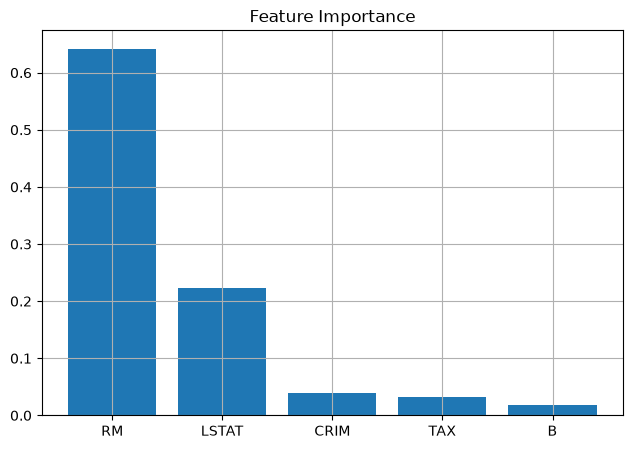

In [12]:
fig = plt.figure(figsize = (7.5, 5))

plt.title("Feature Importance")
plt.bar(feature_importance["Feature"][:5], feature_importance["Importance"][:5])

plt.grid()

plt.show()

In [13]:
top_features_names = list(feature_importance["Feature"][:5])

# Splitting again data in order to avoid errors by pandas concatenations
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

X_train = X_train[top_features_names]
X_test = X_test[top_features_names]

dt_regression_features_importance = DecisionTreeRegressor(
    max_depth = int(best_params["max_depth"]),
    min_samples_split = best_params["min_samples_split"],
    min_samples_leaf = best_params["min_samples_leaf"],
    max_features = best_params["max_features"],
    random_state = 42
).fit(X = X_train, y = y_train)

y_pred_features_importance = dt_regression_features_importance.predict(X_test)

mse_features_importance = mean_squared_error(y_true = y_test, y_pred = y_pred_features_importance)

print(f"Scaled regression DT max_depth = {int(best_params["max_depth"])}, min_samples_split = {best_params["min_samples_split"]}, " +
      f"min_samples_leaf = {best_params["min_samples_leaf"]}, max_features = {best_params["max_features"]} achieved {mse_features_importance:.2f} MSE.")

Scaled regression DT max_depth = 12, min_samples_split = 2, min_samples_leaf = 1, max_features = 0.7 achieved 31.60 MSE.


### Conclusions
Looking at the MSE values we can describe our results as follows:
- **Part 1**, MSE = 27.16
- **Part 2**, MSE = 25.74
- **Part 3**, MSE = 31.60

By selecting the 5 most important features from the predictor space we don't obtain better results, indeed we obtained the worst MSE value of all three experiments. The best result was achieved through standardization, so the Regression Decision Tree can be influenced by the distribution of the training and testing data.